<a href="https://colab.research.google.com/github/hkiju9-dev/AI-Based-Skin-cancer-detection/blob/master/Skin_Cancer_Stage1_Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Skin Cancer Detection — Stage 1: Dataset + Preprocessing + Baseline Transfer Learning Model

**Research Proposal:** Deep Learning-Based Skin Cancer Detection Under Class Imbalance and Limited Data Constraints

**This notebook covers (Week 1–2 of the Gantt chart):**
1. Download & explore the HAM10000 dataset
2. Visualize the class imbalance problem
3. Preprocess images (resize, normalize, train/val/test split)
4. Apply data augmentation (training set only)
5. Build a baseline transfer learning model (ResNet-50)
6. Train and evaluate the baseline
7. Save the model and results (this becomes the baseline to beat with GAN + few-shot learning in later stages)

**How to run this:** Open in Google Colab, set Runtime → Change runtime type → GPU, then run cells top to bottom.


## 1. Setup — Install & Import Libraries

In [1]:
# Run once per Colab session
!pip install -q kagglehub tensorflow scikit-learn seaborn opencv-python-headless


In [2]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Download the HAM10000 Dataset

HAM10000 = "Human Against Machine with 10000 training images" — 10,015 dermoscopic images across 7 skin lesion classes.

**Option A (recommended — automatic download via kagglehub):**
Run the cell below. The first time, it will ask you to authenticate with your Kaggle account (you need a free Kaggle account + API token: Kaggle → Account → Create New API Token → upload `kaggle.json` when prompted).

**Option B (manual):**
1. Download from: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
2. Upload the zip to Colab and unzip it into a folder called `ham10000/`


In [3]:
import kagglehub

# Downloads the dataset and returns the local path
dataset_path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset downloaded to:", dataset_path)

# List what's inside
for root, dirs, files in os.walk(dataset_path):
    print(root, "->", len(files), "files")


Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset downloaded to: /kaggle/input/skin-cancer-mnist-ham10000
/kaggle/input/skin-cancer-mnist-ham10000 -> 5 files
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1 -> 5000 files
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_1 -> 5000 files
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2 -> 5015 files
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2 -> 5015 files


## 3. Load Metadata & Explore the Class Imbalance

This is where we **see the P1 problem (class imbalance)** from the proposal with real numbers.


In [4]:
# Load the metadata CSV (contains image IDs and diagnosis labels)
metadata_path = os.path.join(dataset_path, "HAM10000_metadata.csv")
df = pd.read_csv(metadata_path)

print("Total images:", len(df))
print("\nColumns:", df.columns.tolist())
df.head()


Total images: 10015

Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


/tmp/ipykernel_1277/102121331.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


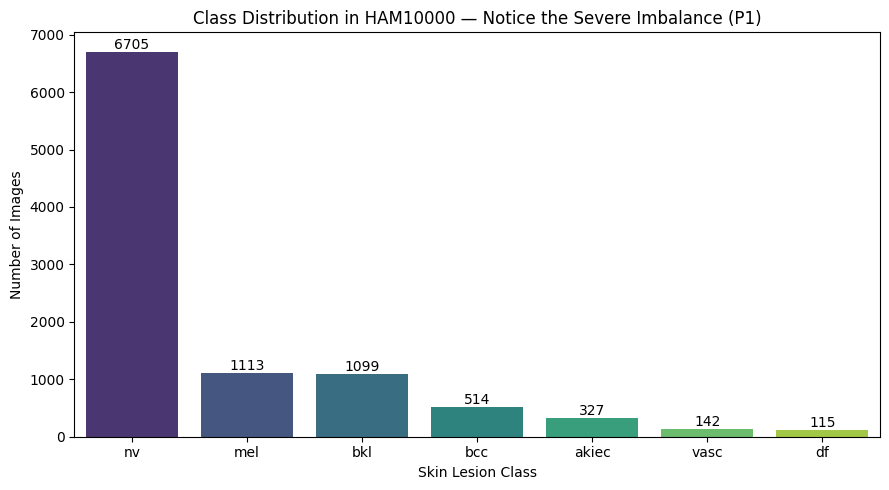


Majority class 'nv' has 6705 images.
Minority class has only 115 images.
Imbalance ratio: 58.3 : 1


In [5]:
# Class label meanings:
# akiec = Actinic keratoses          bcc   = Basal cell carcinoma
# bkl   = Benign keratosis-like       df    = Dermatofibroma
# mel   = Melanoma (MALIGNANT)        nv    = Melanocytic nevi (BENIGN, majority class)
# vasc  = Vascular lesions

label_map = {
    'akiec': 'Actinic keratoses', 'bcc': 'Basal cell carcinoma',
    'bkl': 'Benign keratosis', 'df': 'Dermatofibroma',
    'mel': 'Melanoma', 'nv': 'Melanocytic nevi', 'vasc': 'Vascular lesions'
}

class_counts = df['dx'].value_counts()
print(class_counts)

plt.figure(figsize=(9, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Class Distribution in HAM10000 — Notice the Severe Imbalance (P1)")
plt.xlabel("Skin Lesion Class")
plt.ylabel("Number of Images")
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 50, str(v), ha='center')
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

print(f"\nMajority class 'nv' has {class_counts.max()} images.")
print(f"Minority class has only {class_counts.min()} images.")
print(f"Imbalance ratio: {class_counts.max() / class_counts.min():.1f} : 1")


## 4. Binary Relabeling (Benign vs Malignant) — Optional Simplification

The proposal frames this as benign vs malignant classification. `mel` (melanoma) and `bcc`/`akiec` are
generally treated as malignant/pre-malignant; the rest as benign. Adjust this mapping if your task
requires the full 7-class problem instead.


binary_label
benign       8061
malignant    1954
Name: count, dtype: int64


/tmp/ipykernel_1277/334961208.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='binary_label', data=df, palette="Set2")


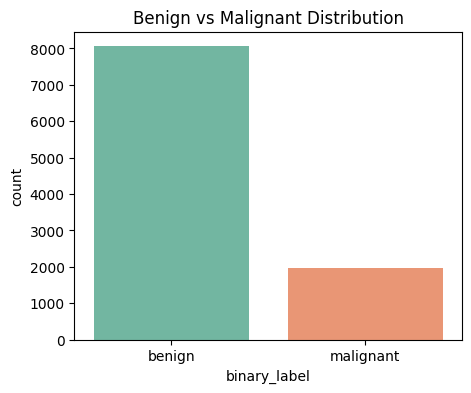

In [6]:
malignant_classes = ['mel', 'bcc', 'akiec']
df['binary_label'] = df['dx'].apply(lambda x: 'malignant' if x in malignant_classes else 'benign')

print(df['binary_label'].value_counts())

plt.figure(figsize=(5, 4))
sns.countplot(x='binary_label', data=df, palette="Set2")
plt.title("Benign vs Malignant Distribution")
plt.show()


## 5. Build Image File Paths & Preprocess

In [7]:
# HAM10000 images are usually split across two folders (part_1, part_2)
image_folders = [os.path.join(dataset_path, d) for d in os.listdir(dataset_path) if 'part' in d.lower()]
if not image_folders:
    # fallback: search recursively for any folder containing .jpg files
    image_folders = []
    for root, dirs, files in os.walk(dataset_path):
        if any(f.endswith('.jpg') for f in files):
            image_folders.append(root)

image_paths = {}
for folder in image_folders:
    for fname in os.listdir(folder):
        if fname.endswith('.jpg'):
            image_id = fname.replace('.jpg', '')
            image_paths[image_id] = os.path.join(folder, fname)

df['image_path'] = df['image_id'].map(image_paths)
df = df.dropna(subset=['image_path']).reset_index(drop=True)
print("Images successfully matched:", len(df))


Images successfully matched: 10015


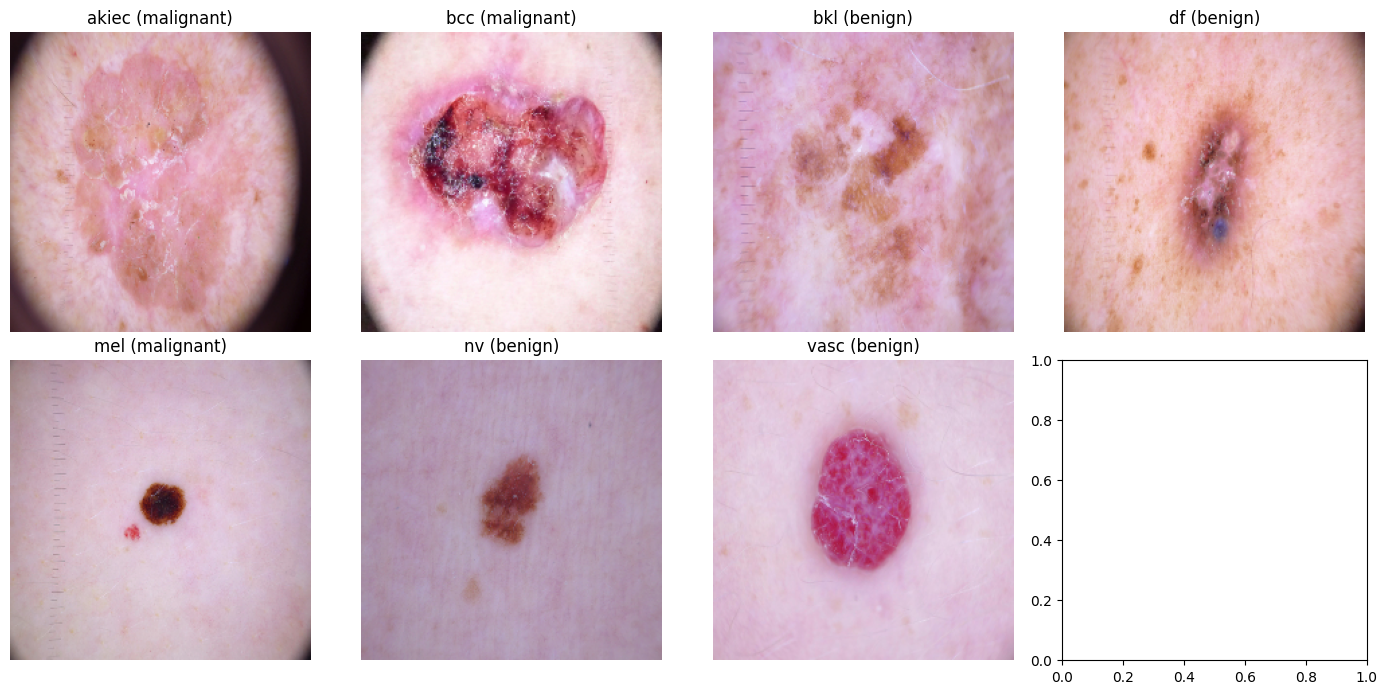

In [8]:
IMG_SIZE = 224  # ResNet-50 default input size

def load_and_preprocess_image(path, size=IMG_SIZE):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    return img

# Quick visual check — plot a few sample images per class
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
sample_df = df.groupby('dx').first().reset_index()
for ax, (_, row) in zip(axes.flatten(), sample_df.iterrows()):
    img = load_and_preprocess_image(row['image_path'])
    ax.imshow(img)
    ax.set_title(f"{row['dx']} ({row['binary_label']})")
    ax.axis('off')
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150)
plt.show()


## 6. Train / Validation / Test Split

Stratified split so the imbalance ratio is preserved consistently across all three sets.


In [9]:
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df['binary_label'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['binary_label'], random_state=42
)

print("Train:", len(train_df), "| Validation:", len(val_df), "| Test:", len(test_df))
print("\nTrain class balance:\n", train_df['binary_label'].value_counts(normalize=True))


Train: 7010 | Validation: 1502 | Test: 1503

Train class balance:
 binary_label
benign       0.80485
malignant    0.19515
Name: proportion, dtype: float64


## 7. Data Augmentation (Training Set Only)

As specified in the proposal (Section 5): flip, rotation, contrast/brightness, zoom — applied ONLY to
training data, never to validation/test data.


In [10]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    zoom_range=0.15,
)

# No augmentation for validation/test — only preprocessing
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

BATCH_SIZE = 32

train_generator = train_datagen.flow_from_dataframe(
    train_df, x_col='image_path', y_col='binary_label',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    val_df, x_col='image_path', y_col='binary_label',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    test_df, x_col='image_path', y_col='binary_label',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

print("Class index mapping:", train_generator.class_indices)


Found 7010 validated image filenames belonging to 2 classes.
Found 1502 validated image filenames belonging to 2 classes.
Found 1503 validated image filenames belonging to 2 classes.
Class index mapping: {'benign': 0, 'malignant': 1}


## 8. Handle Class Imbalance with Class Weights (Interim Fix — GAN Comes in Stage 2)

Before we build the GAN-based augmentation (next stage), we apply a simple but effective
interim fix: class weighting, so the loss function penalizes mistakes on the minority
(malignant) class more heavily.


In [11]:
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)


Class weights: {0: np.float64(0.6212336051045728), 1: np.float64(2.5621345029239766)}


## 9. Build the Baseline Model — ResNet-50 Transfer Learning

Matches the proposal's methodology (Section 5–6): pre-trained ResNet-50 backbone (ImageNet weights),
frozen initially, with a custom classification head on top.


In [12]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False  # freeze backbone for initial training

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(1, activation='sigmoid')(x)  # binary: benign vs malignant

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 10. Train the Baseline Model

In [13]:
callbacks = [
    EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True),
    ModelCheckpoint('baseline_resnet50.keras', monitor='val_auc', mode='max', save_best_only=True)
]

EPOCHS = 20

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 0.7144 - auc: 0.7957 - loss: 0.5549 - precision: 0.3816 - recall: 0.7471 - val_accuracy: 0.7889 - val_auc: 0.8655 - val_loss: 0.4455 - val_precision: 0.4753 - val_recall: 0.7884
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 173s 785ms/step - accuracy: 0.7593 - auc: 0.8583 - loss: 0.4636 - precision: 0.4356 - recall: 0.7887 - val_accuracy: 0.7696 - val_auc: 0.8772 - val_loss: 0.4589 - val_precision: 0.4519 - val_recall: 0.8498
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 174s 790ms/step - accuracy: 0.7673 - auc: 0.8726 - loss: 0.4387 - precision: 0.4474 - recall: 0.8173 - val_accuracy: 0.7856 - val_auc: 0.8817 - val_loss: 0.4474 - val_precision: 0.4725 - val_recall: 0.8498
Epoch 4/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 174s 789ms/step - accuracy: 0.7840 - auc: 0.8822 - loss: 0.4230 - precision: 0.4699 - recall: 0.8326 - val_accuracy: 0.7783 - val_auc: 0.8866 - val_loss: 0.4417 - val_precision: 0.4628 - val_recall: 0.8498
Epoch 5/20
220/220 

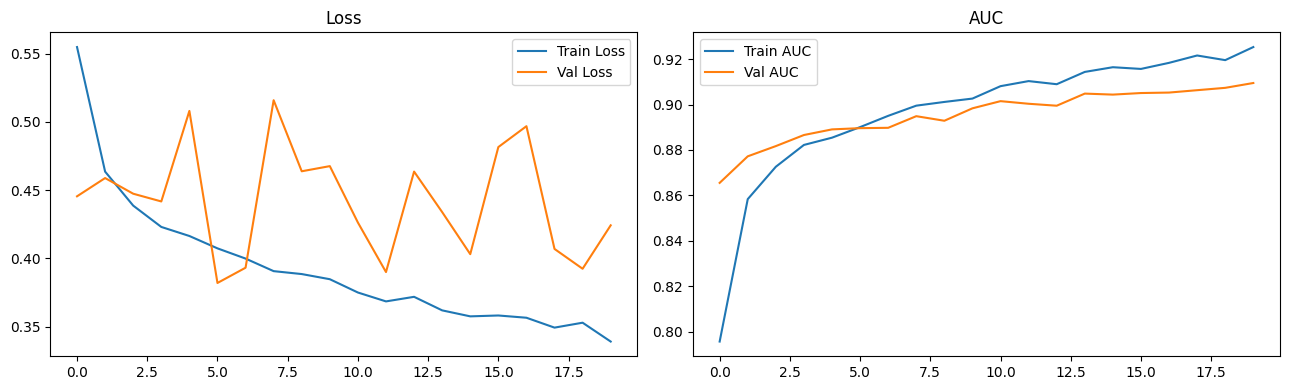

In [14]:
# Plot training curves — check for overfitting/underfitting (Fig. 14 concept from the paper)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(history.history['auc'], label='Train AUC')
axes[1].plot(history.history['val_auc'], label='Val AUC')
axes[1].set_title('AUC'); axes[1].legend()
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()


## 11. Evaluate on the Held-Out Test Set

We report the exact metrics named in the proposal (Section 4 & 6): Accuracy, Precision, Recall,
F1-score, AUC-ROC — with special attention to malignant-class recall/sensitivity, since that is the
clinically critical number (missing a malignant case is far worse than a false alarm).


47/47 ━━━━━━━━━━━━━━━━━━━━ 34s 649ms/step
Class mapping: {'benign': 0, 'malignant': 1}

=== Classification Report ===
              precision    recall  f1-score   support

      benign       0.97      0.76      0.85      1210
   malignant       0.47      0.89      0.62       293

    accuracy                           0.79      1503
   macro avg       0.72      0.83      0.74      1503
weighted avg       0.87      0.79      0.81      1503

AUC-ROC: 0.9112


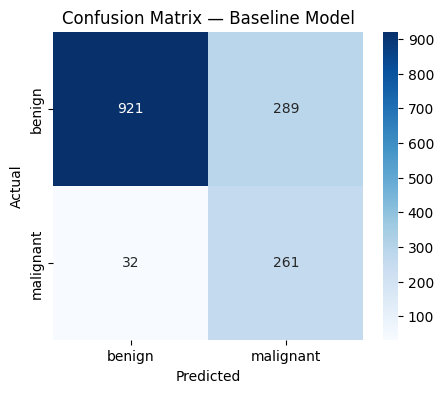

In [15]:
test_generator.reset()
y_pred_prob = model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_generator.classes

print("Class mapping:", test_generator.class_indices)
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))

auc_score = roc_auc_score(y_true, y_pred_prob)
print(f"AUC-ROC: {auc_score:.4f}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.title("Confusion Matrix — Baseline Model")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.savefig("confusion_matrix_baseline.png", dpi=150)
plt.show()


## 12. Save the Baseline Model & Results

This baseline model + its metrics become the reference point that GAN-based augmentation and
few-shot learning (Stage 2 and Stage 3 notebooks) must beat.


In [16]:
model.save("baseline_resnet50_final.keras")

results_summary = {
    "model": "ResNet-50 (frozen backbone) + class weighting",
    "test_auc": float(auc_score),
    "epochs_trained": len(history.history['loss']),
}
import json
with open("baseline_results.json", "w") as f:
    json.dump(results_summary, f, indent=2)

print("Saved: baseline_resnet50_final.keras, baseline_results.json")
print(results_summary)


Saved: baseline_resnet50_final.keras, baseline_results.json
{'model': 'ResNet-50 (frozen backbone) + class weighting', 'test_auc': 0.9111612557470454, 'epochs_trained': 20}


---
## Next Steps (Stage 2 & 3 — separate notebooks)

1. **Stage 2 — GAN-based augmentation:** Train a DCGAN on the malignant-class images only, generate
   synthetic malignant samples, retrain the same ResNet-50 model on the rebalanced dataset, and
   compare recall/AUC against this baseline.
2. **Stage 3 — Few-shot learning:** Implement a Prototypical Network for the rarest classes
   (e.g., `df`, `vasc`) where even GAN augmentation may not fully compensate for scarce data.
3. **Fine-tuning:** Unfreeze the top layers of ResNet-50 and fine-tune at a lower learning rate for
   a further accuracy boost.

Let me know when you're ready for Stage 2 and I will build the GAN augmentation notebook next.
